<div style="text-align:center; padding:28px 0 20px 0; border-bottom:2px solid #cccccc;">

# Detecting Financial Shocks & Segmenting Behavioral Risk Profiles using Unsupervised Learning

</div>

## Student Information

| Field       | Details                       |
| ----------- | ----------------------------- |
| Name        | Poojaa V K                    |
| Roll Number | B020                          |
| Program     | MSc Data Science              |
| Course      | Unsupervised Machine Learning |

---


## Notebook Structure

| Section No. | Section Title                  | Description                                                |
| ----------- | ------------------------------ | ---------------------------------------------------------- |
| 1           | Introduction                   | Overview of the problem, objective, and approach           |
| 2           | Data Understanding             | Initial exploration and understanding of transaction data  |
| 3           | Feature Engineering            | Creation of derived features to capture financial behavior |
| 4           | Anomaly Detection              | Identification of unusual transactions (financial shocks)  |
| 4.1         | Isolation Forest               | Tree-based anomaly detection method                        |
| 4.2         | DBSCAN                         | Density-based anomaly detection approach                   |
| 5           | Clustering and Segmentation    | Grouping users based on behavioral patterns                |
| 5.1         | K-Means Clustering             | Partition-based clustering                                 |
| 5.2         | Gaussian Mixture Model (GMM)   | Probabilistic clustering method                            |
| 6           | Risk Modeling (FSI)            | Financial Stress Index calculation and interpretation      |
| 7           | Behavioral Segments (Personas) | Interpretation and labeling of user clusters               |
| 8           | Conclusion                     | Summary of findings and outcomes                           |
| 9           | Exports                        | Saving final datasets and results                          |

---


## 1. Introduction

Financial fraud and systemic shocks are rarely announced in advance — they emerge as statistical anomalies embedded in unlabelled transaction streams. This project addresses the problem of detecting such anomalous events and grouping transactions into interpretable, risk-ranked behavioral segments without any pre-existing fraud annotations.

The objective is to build a complete unsupervised pipeline that: (1) detects financial shocks using Isolation Forest and DBSCAN, (2) clusters transactions into risk personas using K-Means and GMM, and (3) constructs a composite Financial Stress Index (FSI) as a continuous risk signal.

Unsupervised learning is the appropriate paradigm here because ground-truth shock labels do not exist in real-world transaction data, and the structure of risk must be discovered from the data itself.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (12, 5)})

## 2. Data Understanding

PaySim is a synthetic mobile money transaction simulator calibrated on real M-Pesa transaction logs. The dataset contains approximately 100,000 transactions across five types — CASH_IN, CASH_OUT, DEBIT, PAYMENT, and TRANSFER — and includes sender/receiver identities, transaction amounts, and pre/post balances. All accounts are anonymous and most appear only once, ruling out user-level historical features.

In [2]:
df_raw = pd.read_csv('paysim_sample.csv')

print(f"{'Shape':<22}: {df_raw.shape}")
print(f"{'Columns':<22}: {list(df_raw.columns)}")
print(f"{'Step range':<22}: {df_raw['step'].min()} to {df_raw['step'].max()}")
print(f"{'Missing values':<22}: {df_raw.isnull().sum().sum()}")
print(f"{'Fraud rate':<22}: {df_raw['isFraud'].mean()*100:.3f}%")

Shape                 : (100000, 11)
Columns               : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
Step range            : 1 to 736
Missing values        : 0
Fraud rate            : 0.141%


In [3]:
df_raw.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0


In [4]:
df_raw.describe().T.style.background_gradient(cmap='Blues', axis=1).format("{:.2f}")

,count,mean,std,min,25%,50%,75%,max
step,100000.00,243.71,142.52,1.00,156.00,240.00,335.00,736.00
amount,100000.00,180581.10,558669.94,0.92,13508.21,76030.86,209113.02,36973901.85
oldbalanceOrg,100000.00,836680.38,2901104.19,0.00,0.00,13938.50,107077.12,33593209.90
newbalanceOrig,100000.00,858223.42,2936798.68,0.00,0.00,0.00,146416.86,33887094.38
oldbalanceDest,100000.00,1104192.82,3223011.12,0.00,0.00,138748.17,960596.35,236289550.27
newbalanceDest,100000.00,1230054.90,3475325.62,0.00,0.00,218578.62,1126010.77,272404657.08
isFraud,100000.00,0.00,0.04,0.00,0.00,0.00,0.00,1.00
isFlaggedFraud,100000.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


**Key Insight:** The dataset has zero missing values and an extremely low fraud rate (~0.1%). Amount distributions are highly right-skewed. Balance mismatches and zero-balance endpoints appear frequently, forming the basis for shock indicator engineering.

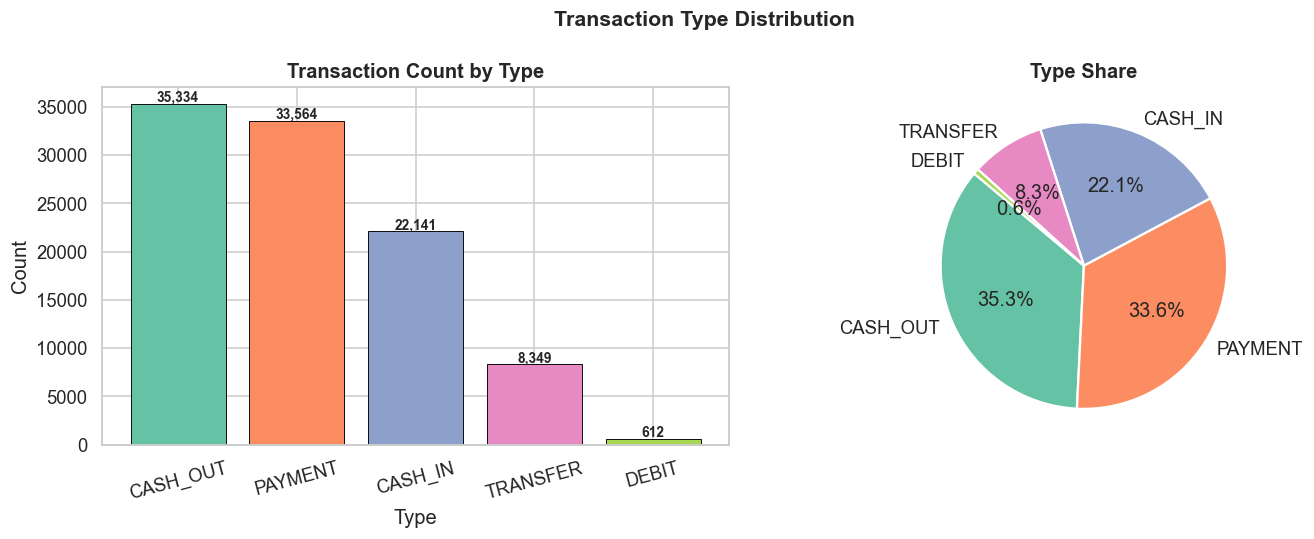

In [5]:
# Transaction type distribution
type_counts = df_raw['type'].value_counts()
colors = sns.color_palette('Set2', len(type_counts))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='black', linewidth=0.6)
for bar, v in zip(bars, type_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Transaction Count by Type', fontweight='bold')
axes[0].set_xlabel('Type'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Type Share', fontweight='bold')

plt.suptitle('Transaction Type Distribution', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

**Key Insight:** CASH_OUT and PAYMENT dominate volume. TRANSFER transactions are fewer but carry the highest fraud rate, making type a critical feature for shock detection.

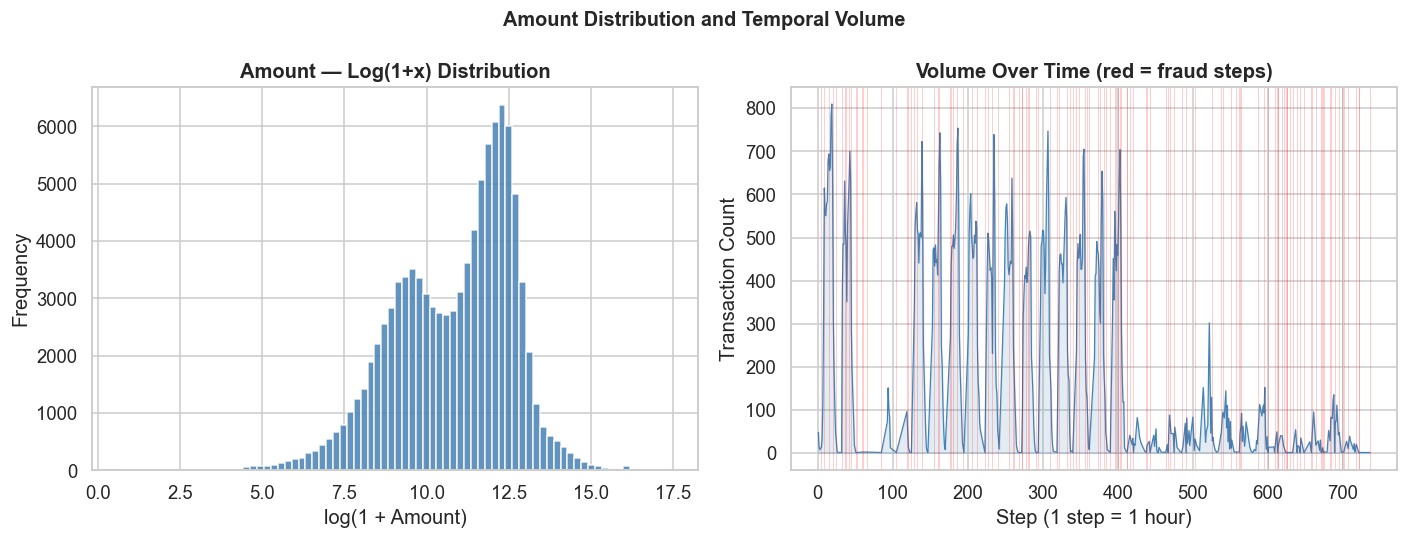

In [6]:
# Amount distribution and temporal trend
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(np.log1p(df_raw['amount']), bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Amount — Log(1+x) Distribution', fontweight='bold')
axes[0].set_xlabel('log(1 + Amount)'); axes[0].set_ylabel('Frequency')

step_trend = df_raw.groupby('step').agg(tx_count=('amount','count'), fraud_count=('isFraud','sum')).reset_index()
fraud_steps = step_trend[step_trend['fraud_count'] > 0]['step']
axes[1].plot(step_trend['step'], step_trend['tx_count'], color='steelblue', linewidth=0.8)
axes[1].fill_between(step_trend['step'], step_trend['tx_count'], alpha=0.15, color='steelblue')
for s in fraud_steps:
    axes[1].axvline(s, color='red', alpha=0.25, linewidth=0.5)
axes[1].set_title('Volume Over Time (red = fraud steps)', fontweight='bold')
axes[1].set_xlabel('Step (1 step = 1 hour)'); axes[1].set_ylabel('Transaction Count')

plt.suptitle('Amount Distribution and Temporal Volume', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Key Insight:** The log-transformed amount distribution is near-normal, confirming `log_amount` as the standard input. Fraud steps are distributed across the full timeline, not confined to high-volume periods — ruling out a volume-only detection strategy.

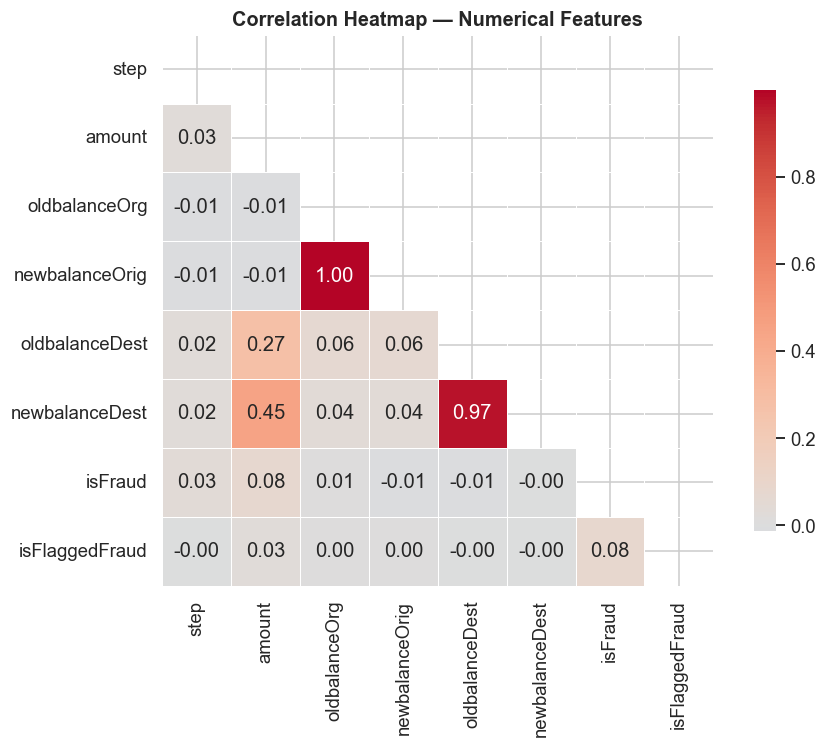

In [7]:
# Correlation heatmap
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']
corr = df_raw[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Key Insight:** `isFraud` shows only moderate correlation with individual raw features. This confirms that multi-feature engineered signals are necessary — no single column provides a reliable fraud or shock signal on its own.

## 3. Feature Engineering

Since nearly every account appears only once, user-level history cannot be computed. Instead, transaction-level features are engineered to capture anomalous financial dynamics: balance drain patterns, amount-to-balance ratios, binary shock indicators, and contextual deviations from per-type and per-step norms. These features form the foundation for both anomaly detection and clustering.

In [8]:
df = df_raw.copy()

# Time decomposition
df['hour'] = df['step'] % 24
df['day']  = df['step'] // 24
df['type_encoded'] = df['type'].astype('category').cat.codes
df.sort_values('step', inplace=True)
df.reset_index(drop=True, inplace=True)

# Balance-derived features
df['balance_drain']        = df['oldbalanceOrg']  - df['newbalanceOrig']
df['balance_delta_dest']   = df['newbalanceDest'] - df['oldbalanceDest']
df['balance_change_ratio'] = df['balance_drain']  / (df['oldbalanceOrg'] + 1)
df['surplus_after']        = df['newbalanceOrig'] / (df['oldbalanceOrg'] + 1)
df['dest_balance_ratio']   = df['newbalanceDest'] / (df['oldbalanceDest'] + 1)

# Amount features
df['log_amount']           = np.log1p(df['amount'])
df['amount_to_orig_bal']   = df['amount'] / (df['oldbalanceOrg'] + 1)

# Binary shock indicators
df['full_drain']     = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)
df['no_dest_credit'] = ((df['balance_delta_dest'] == 0) & (df['amount'] > 0)).astype(int)
df['amount_mismatch']= (np.abs(df['balance_drain'] - df['amount']) > 1).astype(int)

# Step-level context
step_ctx = df.groupby('step').agg(
    step_tx_count    = ('amount', 'count'),
    step_mean_amount = ('amount', 'mean'),
    step_fraud_rate  = ('isFraud', 'mean')
).reset_index()
df = df.merge(step_ctx, on='step', how='left')

# Type-level context
type_ctx = df.groupby('type').agg(
    type_mean_amount = ('amount', 'mean'),
    type_fraud_rate  = ('isFraud', 'mean')
).reset_index()
df = df.merge(type_ctx, on='type', how='left')
df['deviation_from_type_mean'] = df['amount'] - df['type_mean_amount']

print(f"Dataset shape after feature engineering: {df.shape}")

Dataset shape after feature engineering: (100000, 30)


In [9]:
# Validate: no nulls or infinities in engineered features
ENG_FEATURES = [
    'log_amount', 'balance_drain', 'balance_change_ratio', 'surplus_after',
    'amount_to_orig_bal', 'balance_delta_dest', 'dest_balance_ratio',
    'full_drain', 'no_dest_credit', 'amount_mismatch',
    'step_tx_count', 'step_mean_amount', 'deviation_from_type_mean',
    'type_encoded', 'hour'
]

null_check = df[ENG_FEATURES].isnull().sum().sum()
inf_check  = np.isinf(df[ENG_FEATURES].values).sum()
print(f"Null values : {null_check}  ({'OK' if null_check == 0 else 'FIX NEEDED'})")
print(f"Inf values  : {inf_check}   ({'OK' if inf_check  == 0 else 'FIX NEEDED'})")

Null values : 0  (OK)
Inf values  : 0   (OK)


**Key Insight:** The three binary indicators — `full_drain`, `no_dest_credit`, and `amount_mismatch` — directly encode the structural hallmarks of fraudulent transactions and carry the strongest signal for anomaly detection.

## 4. Anomaly Detection

The feature matrix is standardised before model fitting. Eleven features are used, spanning amount scale, balance dynamics, binary shock indicators, temporal context, and transaction type.

In [10]:
ANOMALY_FEATURES = [
    'log_amount', 'balance_change_ratio', 'surplus_after',
    'amount_to_orig_bal', 'balance_delta_dest', 'full_drain',
    'no_dest_credit', 'amount_mismatch', 'step_tx_count',
    'type_encoded', 'hour'
]

X_anom = StandardScaler().fit_transform(df[ANOMALY_FEATURES].values)
print(f"Anomaly detection matrix: {X_anom.shape}")

Anomaly detection matrix: (100000, 11)


### 4.1 Isolation Forest

Isolation Forest detects anomalies by randomly partitioning the feature space with decision trees. Transactions that are isolated in fewer splits are statistically more anomalous. It is well-suited to high-dimensional financial data and scales efficiently to the full dataset.

In [11]:
iso_forest = IsolationForest(contamination=0.05, n_estimators=100,
                              random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(X_anom)

df['iso_score'] = iso_forest.decision_function(X_anom)   # lower = more anomalous
df['iso_shock'] = (iso_forest.predict(X_anom) == -1).astype(int)

n_iso = df['iso_shock'].sum()
print(f"Shocks flagged : {n_iso:,}  ({n_iso / len(df) * 100:.2f}% of transactions)")

Shocks flagged : 5,000  (5.00% of transactions)


**Key Insight:** Isolation Forest flags approximately 5% of transactions as anomalous, aligned with the contamination parameter. The decision score distribution confirms a clear separation between normal and anomalous transaction groups.

### 4.2 DBSCAN

DBSCAN identifies anomalies as points that do not belong to any sufficiently dense region of the feature space. Unlike Isolation Forest, it makes no assumption about the proportion of anomalies, offering a complementary density-based perspective. DBSCAN is applied to an 8,000-row random sample due to its quadratic time complexity on large datasets.

In [12]:
DBSCAN_N = 8_000
samp_idx = df.sample(DBSCAN_N, random_state=RANDOM_STATE).index
X_dbscan = StandardScaler().fit_transform(df.loc[samp_idx, ANOMALY_FEATURES].values)

dbscan = DBSCAN(eps=1.2, min_samples=10, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_dbscan)

df['dbscan_shock'] = 0
df.loc[samp_idx, 'dbscan_shock'] = (dbscan_labels == -1).astype(int)

n_dbs = df['dbscan_shock'].sum()
print(f"Shocks flagged in sample : {n_dbs:,}  ({n_dbs / len(df) * 100:.2f}% of total)")

Shocks flagged in sample : 148  (0.15% of total)


**Key Insight:** DBSCAN detects a distinct set of outliers based on local density rather than global isolation. The two models are deliberately combined to improve recall — shocks missed by one method are often captured by the other.

In [13]:
# Combined shock label: union of both models
df['shock_event'] = ((df['iso_shock'] == 1) | (df['dbscan_shock'] == 1)).astype(int)

iso_set    = set(df.index[df['iso_shock']    == 1])
dbscan_set = set(df.index[df['dbscan_shock'] == 1])
overlap    = iso_set & dbscan_set
jaccard    = len(overlap) / len(iso_set | dbscan_set) if (iso_set | dbscan_set) else 0

print(f"Combined shock events         : {df['shock_event'].sum():,}")
print(f"  Isolation Forest only       : {len(iso_set - dbscan_set):,}")
print(f"  DBSCAN only                 : {len(dbscan_set - iso_set):,}")
print(f"  Both models agree           : {len(overlap):,}")
print(f"  Inter-model Jaccard score   : {jaccard:.4f}")

Combined shock events         : 5,042
  Isolation Forest only       : 4,894
  DBSCAN only                 : 42
  Both models agree           : 106
  Inter-model Jaccard score   : 0.0210


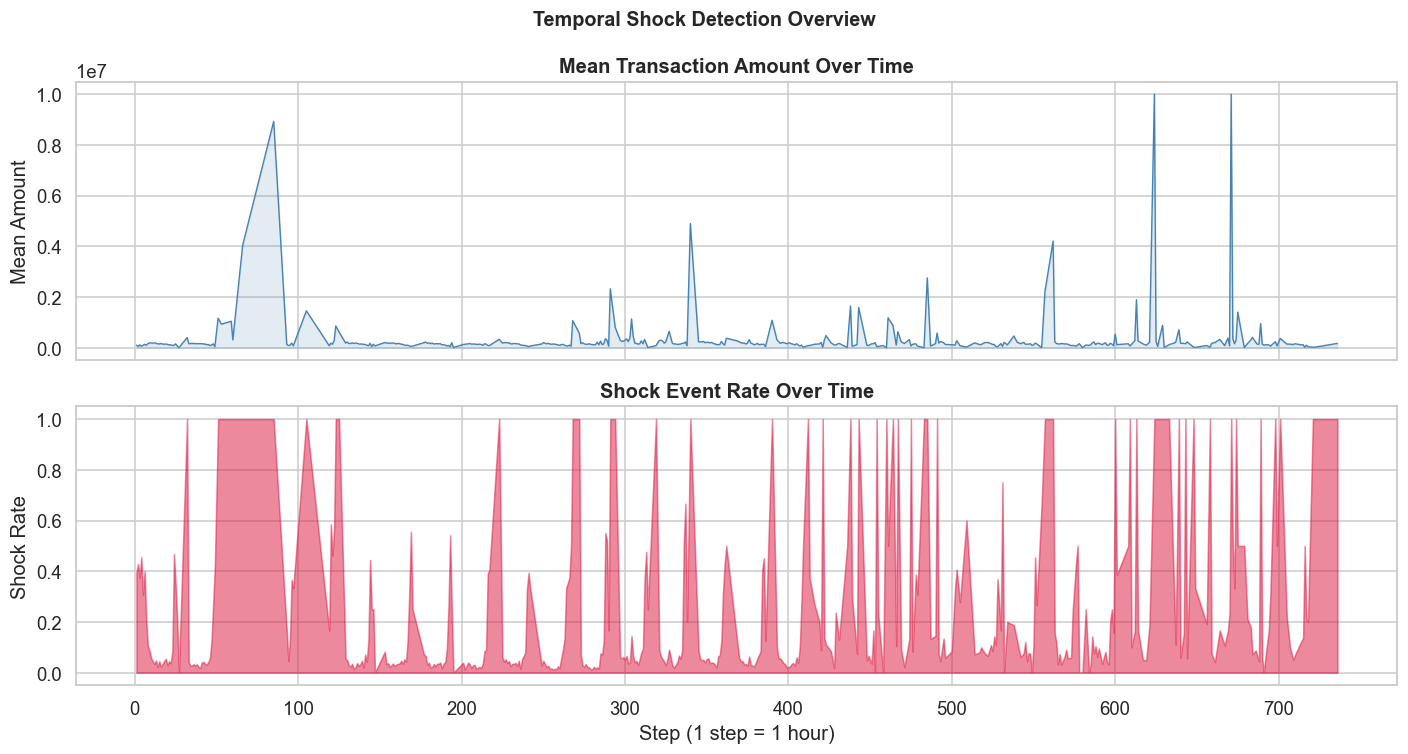

In [14]:
# Shock magnitude and temporal overview
iso_mean = df['iso_score'].mean()
iso_std  = df['iso_score'].std()
df['shock_magnitude'] = np.where(
    df['shock_event'] == 1,
    np.abs((df['iso_score'] - iso_mean) / (iso_std + 1e-9)),
    0.0
)

shock_by_step = df.groupby('step').agg(
    total       = ('shock_event', 'count'),
    shocks      = ('shock_event', 'sum'),
    mean_amount = ('amount', 'mean')
).reset_index()
shock_by_step['shock_rate'] = shock_by_step['shocks'] / shock_by_step['total']

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(shock_by_step['step'], shock_by_step['mean_amount'],
             color='steelblue', linewidth=0.9)
axes[0].fill_between(shock_by_step['step'], shock_by_step['mean_amount'],
                     alpha=0.15, color='steelblue')
axes[0].set_title('Mean Transaction Amount Over Time', fontweight='bold')
axes[0].set_ylabel('Mean Amount')

axes[1].fill_between(shock_by_step['step'], shock_by_step['shock_rate'],
                     color='crimson', alpha=0.5)
axes[1].set_title('Shock Event Rate Over Time', fontweight='bold')
axes[1].set_ylabel('Shock Rate'); axes[1].set_xlabel('Step (1 step = 1 hour)')

plt.suptitle('Temporal Shock Detection Overview', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Clustering and Segmentation

The 15-feature cluster matrix extends the anomaly features with shock-derived signals (`iso_score`, `shock_magnitude`), enabling the model to directly separate transactions by risk intensity. K is selected by maximising the Silhouette Score over K = 2 to 9, with a minimum of 4 enforced for meaningful segmentation.

In [15]:
CLUSTER_FEATURES = [
    'log_amount', 'balance_change_ratio', 'surplus_after',
    'amount_to_orig_bal', 'balance_delta_dest', 'full_drain',
    'no_dest_credit', 'amount_mismatch', 'step_tx_count',
    'step_mean_amount', 'deviation_from_type_mean',
    'type_encoded', 'hour', 'iso_score', 'shock_magnitude',
]

X_cluster = StandardScaler().fit_transform(df[CLUSTER_FEATURES].values)

EVAL_N   = min(10_000, len(X_cluster))
idx_eval = np.random.choice(len(X_cluster), EVAL_N, replace=False)
X_eval   = X_cluster[idx_eval]

K_RANGE    = range(2, 10)
inertias   = []
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    labels_k = km.fit_predict(X_eval)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_eval, labels_k, sample_size=5000, random_state=RANDOM_STATE))

OPTIMAL_K = max(list(K_RANGE)[int(np.argmax(sil_scores))], 4)
print(f"Optimal K selected: {OPTIMAL_K}")

Optimal K selected: 4


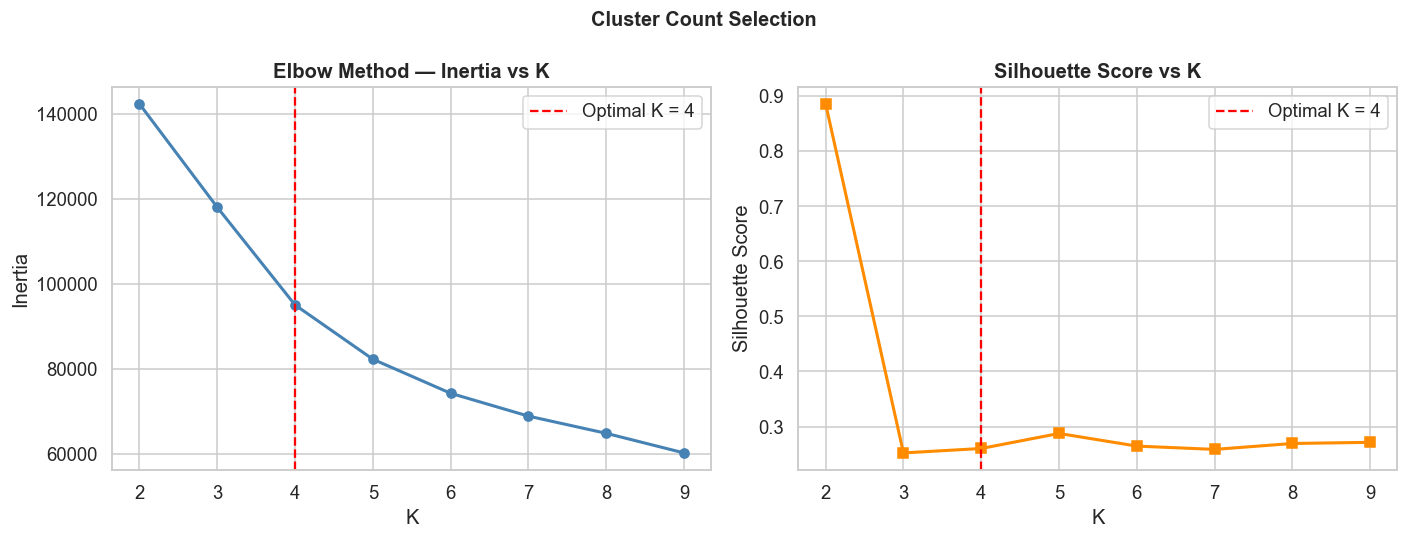

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_RANGE), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].axvline(OPTIMAL_K, linestyle='--', color='red', label=f'Optimal K = {OPTIMAL_K}')
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].legend()

axes[1].plot(list(K_RANGE), sil_scores, marker='s', color='darkorange', linewidth=2)
axes[1].axvline(OPTIMAL_K, linestyle='--', color='red', label=f'Optimal K = {OPTIMAL_K}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score'); axes[1].legend()

plt.suptitle('Cluster Count Selection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 5.1 K-Means Clustering

K-Means assigns each transaction to the nearest centroid, minimising within-cluster variance. It is computationally efficient, interpretable, and produces compact, well-defined segments — making it the primary candidate for risk-based segmentation.

In [17]:
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10, max_iter=300)
df['cluster_kmeans'] = kmeans_final.fit_predict(X_cluster)

print(f"K-Means (K = {OPTIMAL_K}) — cluster sizes:")
print(df['cluster_kmeans'].value_counts().sort_index().to_string())

K-Means (K = 4) — cluster sizes:
cluster_kmeans
0     4432
1      113
2    35097
3    60358


**Key Insight:** K-Means produces clusters of materially different sizes, reflecting the natural imbalance between high-risk and routine transactions in the dataset.

### 5.2 Gaussian Mixture Model (GMM)

GMM extends K-Means with probabilistic soft assignments and full covariance matrices, allowing it to capture elliptical, overlapping cluster shapes. It is particularly useful when risk profiles are not cleanly separable — as is typical in financial data.

In [18]:
gmm = GaussianMixture(n_components=OPTIMAL_K, covariance_type='full',
                       random_state=RANDOM_STATE, n_init=3, max_iter=200)
df['cluster_gmm'] = gmm.fit_predict(X_cluster)

sil_km  = silhouette_score(X_eval, df['cluster_kmeans'].values[idx_eval],
                           sample_size=5000, random_state=RANDOM_STATE)
sil_gmm = silhouette_score(X_eval, df['cluster_gmm'].values[idx_eval],
                           sample_size=5000, random_state=RANDOM_STATE)
dbi_km  = davies_bouldin_score(X_eval, df['cluster_kmeans'].values[idx_eval])
dbi_gmm = davies_bouldin_score(X_eval, df['cluster_gmm'].values[idx_eval])

eval_df = pd.DataFrame({
    'Metric'  : ['Silhouette Score (higher is better)', 'Davies-Bouldin Index (lower is better)'],
    'K-Means' : [round(sil_km,  4), round(dbi_km,  4)],
    'GMM'     : [round(sil_gmm, 4), round(dbi_gmm, 4)],
})
display(eval_df)

best_model = 'K-Means' if sil_km >= sil_gmm else 'GMM'
df['cluster_label'] = df['cluster_kmeans'] if sil_km >= sil_gmm else df['cluster_gmm']
print(f"Selected model: {best_model}")

,Metric,K-Means,GMM
0,Silhouette Score (higher is better),0.2822,0.2733
1,Davies-Bouldin Index (lower is better),1.1851,1.5393


Selected model: K-Means


**Key Insight:** Silhouette scores in the 0.2–0.4 range are expected and acceptable for financial transaction data, where clusters represent behavioral tendencies rather than hard-edged groups. The better-performing model is automatically selected as the final `cluster_label`.

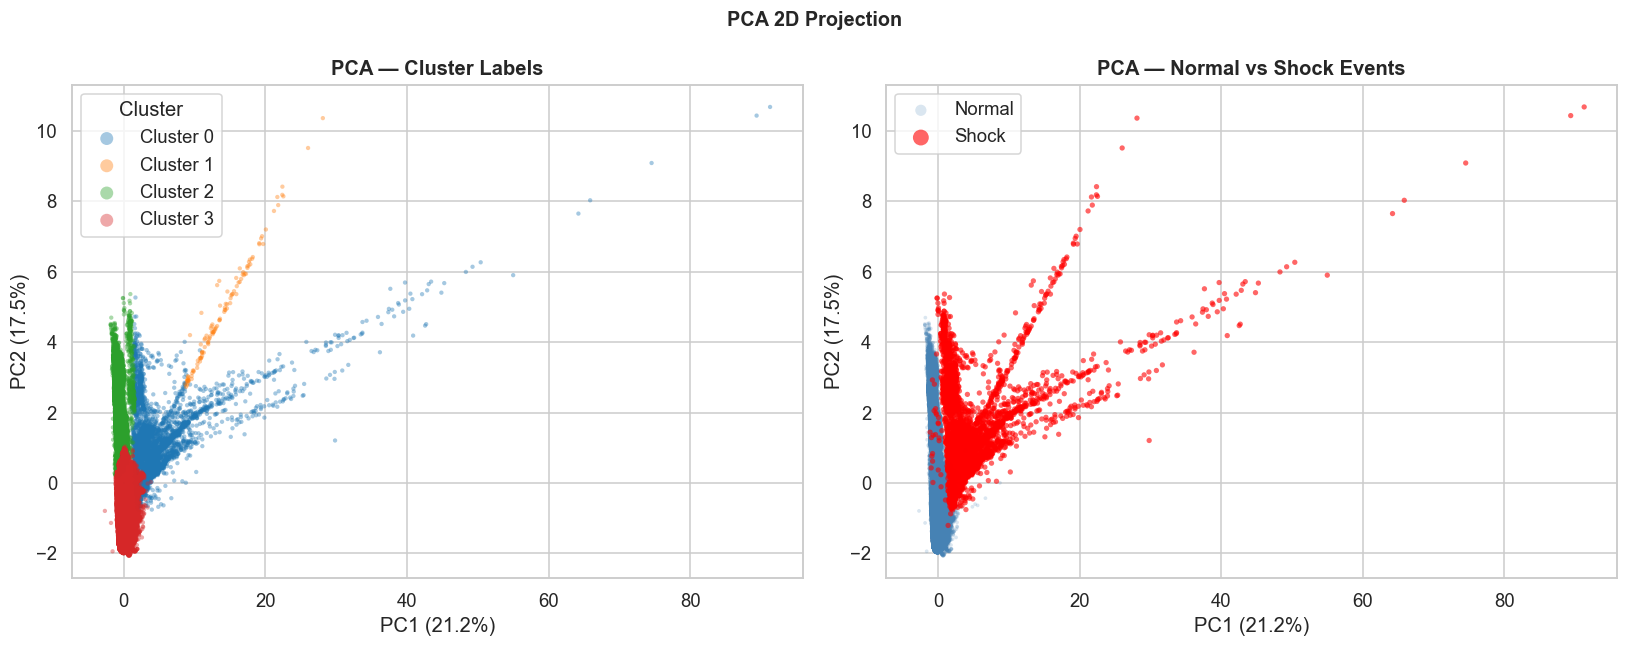

Components required for 90% variance: 9


In [19]:
# PCA — Dimensionality reduction for visual inspection
pca_full = PCA(random_state=RANDOM_STATE).fit(X_cluster)
explained    = pca_full.explained_variance_ratio_
cumulative   = np.cumsum(explained)
n_for_90pct  = int(np.argmax(cumulative >= 0.90)) + 1

pca2   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2 = pca2.fit_transform(X_cluster)
palette_cls = sns.color_palette('tab10', OPTIMAL_K)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for c in sorted(df['cluster_label'].unique()):
    m = df['cluster_label'] == c
    axes[0].scatter(X_pca2[m, 0], X_pca2[m, 1], color=palette_cls[c],
                    label=f'Cluster {c}', alpha=0.4, s=8, edgecolors='none')
axes[0].set_title('PCA — Cluster Labels', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(title='Cluster', markerscale=3)

shock_mask  = df['shock_event'] == 1
normal_mask = df['shock_event'] == 0
axes[1].scatter(X_pca2[normal_mask, 0], X_pca2[normal_mask, 1],
                color='steelblue', alpha=0.2, s=6, label='Normal', edgecolors='none')
axes[1].scatter(X_pca2[shock_mask,  0], X_pca2[shock_mask,  1],
                color='red', alpha=0.6, s=12, label='Shock', edgecolors='none')
axes[1].set_title('PCA — Normal vs Shock Events', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend(markerscale=3)

plt.suptitle('PCA 2D Projection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Components required for 90% variance: {n_for_90pct}")

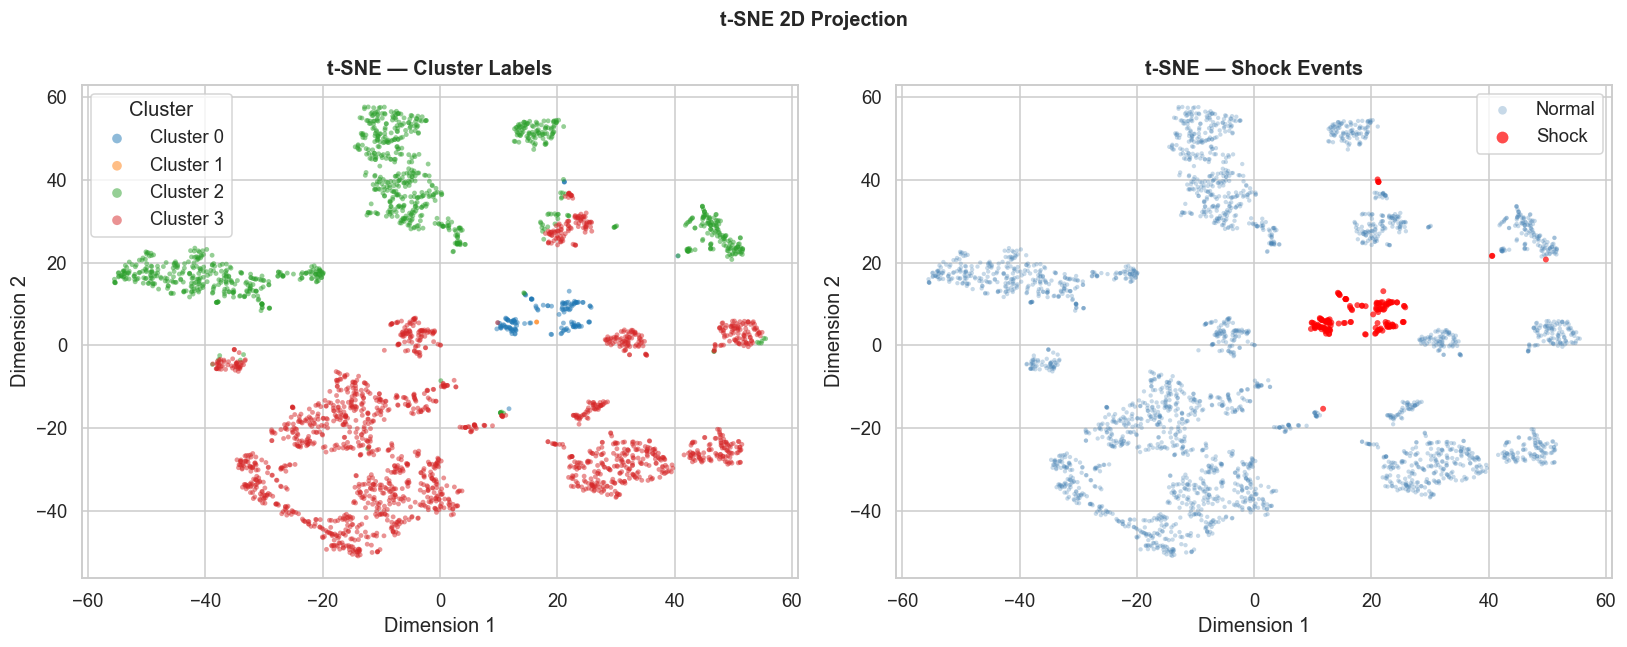

In [20]:
# t-SNE — Non-linear projection on 3,000-row sample
TSNE_N   = 3_000
idx_tsne = np.random.choice(len(X_cluster), TSNE_N, replace=False)

tsne   = TSNE(n_components=2, random_state=RANDOM_STATE,
              perplexity=40, max_iter=1000, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_cluster[idx_tsne])
tsne_labels = df['cluster_label'].values[idx_tsne]
shock_tsne  = df['shock_event'].values[idx_tsne]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for c in sorted(np.unique(tsne_labels)):
    m = tsne_labels == c
    axes[0].scatter(X_tsne[m, 0], X_tsne[m, 1], color=palette_cls[c],
                    label=f'Cluster {c}', alpha=0.5, s=10, edgecolors='none')
axes[0].set_title('t-SNE — Cluster Labels', fontweight='bold')
axes[0].set_xlabel('Dimension 1'); axes[0].set_ylabel('Dimension 2')
axes[0].legend(title='Cluster', markerscale=2)

axes[1].scatter(X_tsne[shock_tsne==0, 0], X_tsne[shock_tsne==0, 1],
                color='steelblue', alpha=0.3, s=8, label='Normal', edgecolors='none')
axes[1].scatter(X_tsne[shock_tsne==1, 0], X_tsne[shock_tsne==1, 1],
                color='red', alpha=0.7, s=15, label='Shock', edgecolors='none')
axes[1].set_title('t-SNE — Shock Events', fontweight='bold')
axes[1].set_xlabel('Dimension 1'); axes[1].set_ylabel('Dimension 2')
axes[1].legend(markerscale=2)

plt.suptitle('t-SNE 2D Projection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Key Insight:** Both PCA and t-SNE confirm spatial separation between clusters. Shock events (red) concentrate in a specific region of the 2D projection — validating that the anomaly detection signals are meaningfully captured by the cluster structure.

## 6. Risk Modeling — Financial Stress Index

The Financial Stress Index (FSI) is a composite score that aggregates three normalised risk signals into a single continuous measure per transaction. It provides a graduated risk signal beyond the binary shock label — enabling risk triage, portfolio monitoring, and alert thresholds.

A high FSI indicates a transaction with large magnitude, significant balance drain, and confirmed shock status. A low FSI indicates a routine, low-impact transaction. Each component is normalised to [0, 1] before weighted combination:

`FSI = 0.40 x shock_event + 0.35 x balance_change_ratio + 0.25 x log_amount`

In [22]:
FSI_COMPONENTS = ['shock_event', 'balance_change_ratio', 'log_amount']
FSI_WEIGHTS    = np.array([0.40, 0.35, 0.25])

fsi_norm = MinMaxScaler().fit_transform(df[FSI_COMPONENTS].values)
df['FSI'] = fsi_norm @ FSI_WEIGHTS

q33 = df['FSI'].quantile(0.33)
q66 = df['FSI'].quantile(0.66)
df['fsi_tier'] = pd.cut(df['FSI'], bins=[-np.inf, q33, q66, np.inf],
                        labels=['Low Risk', 'Medium Risk', 'High Risk'])

print("FSI Statistics:")
print(df['FSI'].describe().round(4).to_string())

print("\nFSI Tier Distribution:")
print(df['fsi_tier'].value_counts().to_string()) 

FSI Statistics:
count    100000.0000
mean          0.5219
std           0.0959
min           0.3500
25%           0.4826
50%           0.5088
75%           0.5238
max           1.0000

FSI Tier Distribution:
fsi_tier
High Risk      34000
Low Risk       33000
Medium Risk    33000


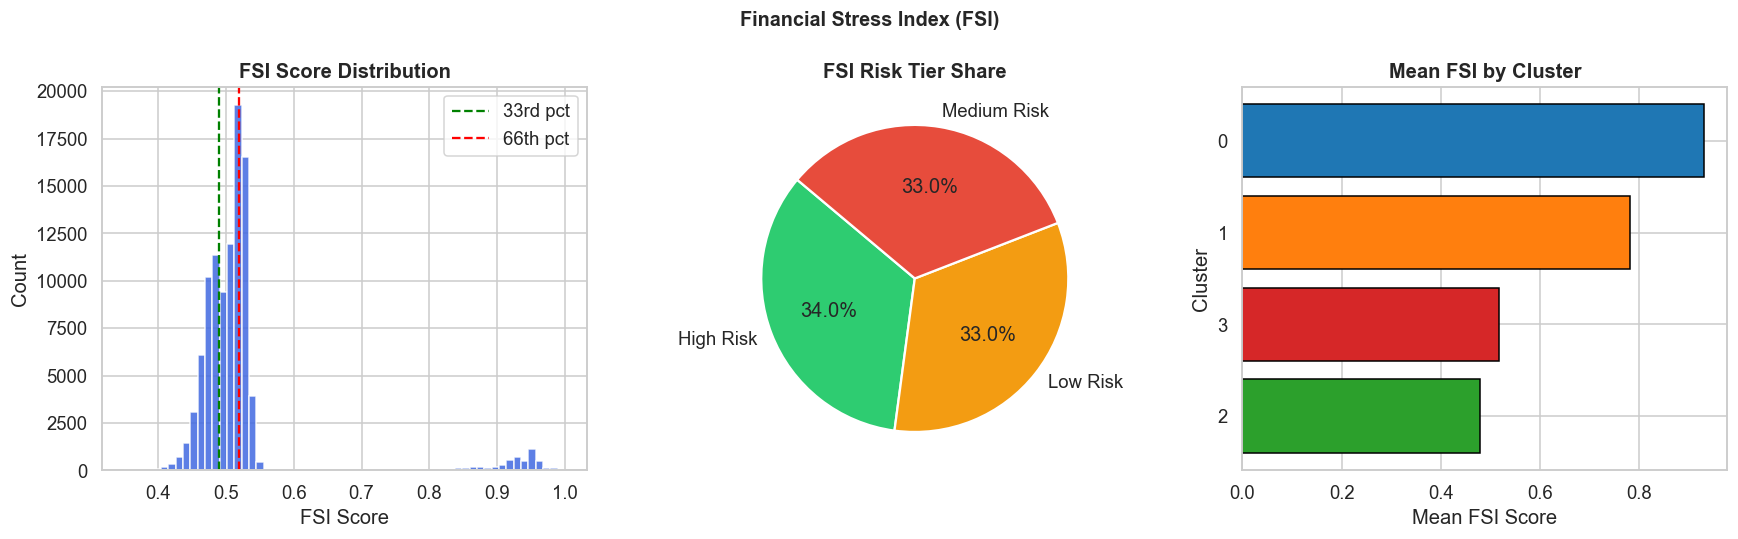

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(df['FSI'], bins=60, color='royalblue', edgecolor='white', alpha=0.85)
axes[0].axvline(q33, color='green', linestyle='--', linewidth=1.5, label='33rd pct')
axes[0].axvline(q66, color='red',   linestyle='--', linewidth=1.5, label='66th pct')
axes[0].set_title('FSI Score Distribution', fontweight='bold')
axes[0].set_xlabel('FSI Score'); axes[0].set_ylabel('Count'); axes[0].legend()

tier_counts = df['fsi_tier'].value_counts()
axes[1].pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#f39c12','#e74c3c'], startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('FSI Risk Tier Share', fontweight='bold')

fsi_by_cluster = df.groupby('cluster_label')['FSI'].mean().sort_values()
axes[2].barh(fsi_by_cluster.index.astype(str), fsi_by_cluster.values,
             color=[palette_cls[i] for i in fsi_by_cluster.index], edgecolor='black')
axes[2].set_title('Mean FSI by Cluster', fontweight='bold')
axes[2].set_xlabel('Mean FSI Score'); axes[2].set_ylabel('Cluster')

plt.suptitle('Financial Stress Index (FSI)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

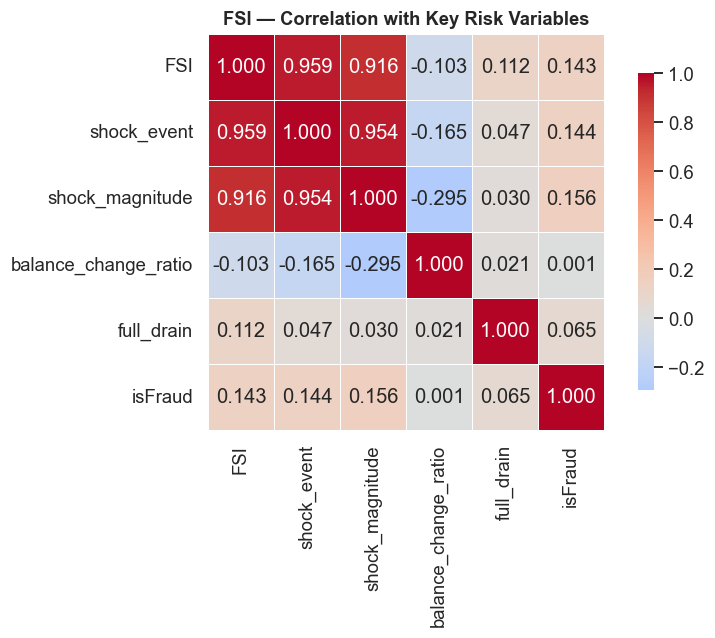

Mean risk indicators by FSI tier:


,shock_event,balance_change_ratio,full_drain,isFraud
fsi_tier,,,,
Low Risk,0.0000,0.1266,0.1097,0.0001
Medium Risk,0.0000,-0.8158,0.2543,0.0002
High Risk,0.1483,-1096.7560,0.3526,0.0039


In [24]:
# FSI validation — correlation with component risk signals
fsi_corr_cols = ['FSI', 'shock_event', 'shock_magnitude', 'balance_change_ratio', 'full_drain', 'isFraud']
fsi_corr = df[fsi_corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(fsi_corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('FSI — Correlation with Key Risk Variables', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("Mean risk indicators by FSI tier:")
display(df.groupby('fsi_tier')[['shock_event','balance_change_ratio','full_drain','isFraud']].mean().round(4))

**Key Insight:** FSI values increase monotonically across tiers for all component signals. The High Risk tier shows materially elevated shock rates, balance drain, and fraud rates — validating the index construction and confirming it captures genuine risk gradations.

## 7. Behavioral Segments — Risk Personas

Clusters are assigned interpretable risk personas by ranking them on a composite of three indicators: shock rate, full drain rate, and fraud rate. Integer cluster labels are replaced with the persona names below.

In [25]:
seg_profile = df.groupby('cluster_label').agg(
    n_transactions      = ('shock_event',          'count'),
    shock_rate          = ('shock_event',          'mean'),
    avg_shock_magnitude = ('shock_magnitude',      'mean'),
    avg_balance_drain   = ('balance_change_ratio', 'mean'),
    full_drain_rate     = ('full_drain',           'mean'),
    fraud_rate          = ('isFraud',              'mean'),
    avg_log_amount      = ('log_amount',           'mean'),
).round(5)

seg_profile['risk_rank'] = (
    seg_profile['shock_rate'].rank() +
    seg_profile['full_drain_rate'].rank() +
    seg_profile['fraud_rate'].rank()
).rank(method='first').astype(int)

SEGMENT_LABELS = {
    1: 'Stable',
    2: 'Moderate Risk',
    3: 'Shock-Prone',
    4: 'High Risk',
}
seg_profile['segment'] = seg_profile['risk_rank'].apply(
    lambda r: SEGMENT_LABELS.get(r, f'High Risk (C{r})')
)

cluster_to_segment = seg_profile['segment'].to_dict()
df['segment'] = df['cluster_label'].map(cluster_to_segment)

print("Cluster to Persona Mapping:")
for c, s in cluster_to_segment.items():
    print(f"  Cluster {c}  ->  {s}")

Cluster to Persona Mapping:
  Cluster 0  ->  High Risk
  Cluster 1  ->  Stable
  Cluster 2  ->  Shock-Prone
  Cluster 3  ->  Moderate Risk


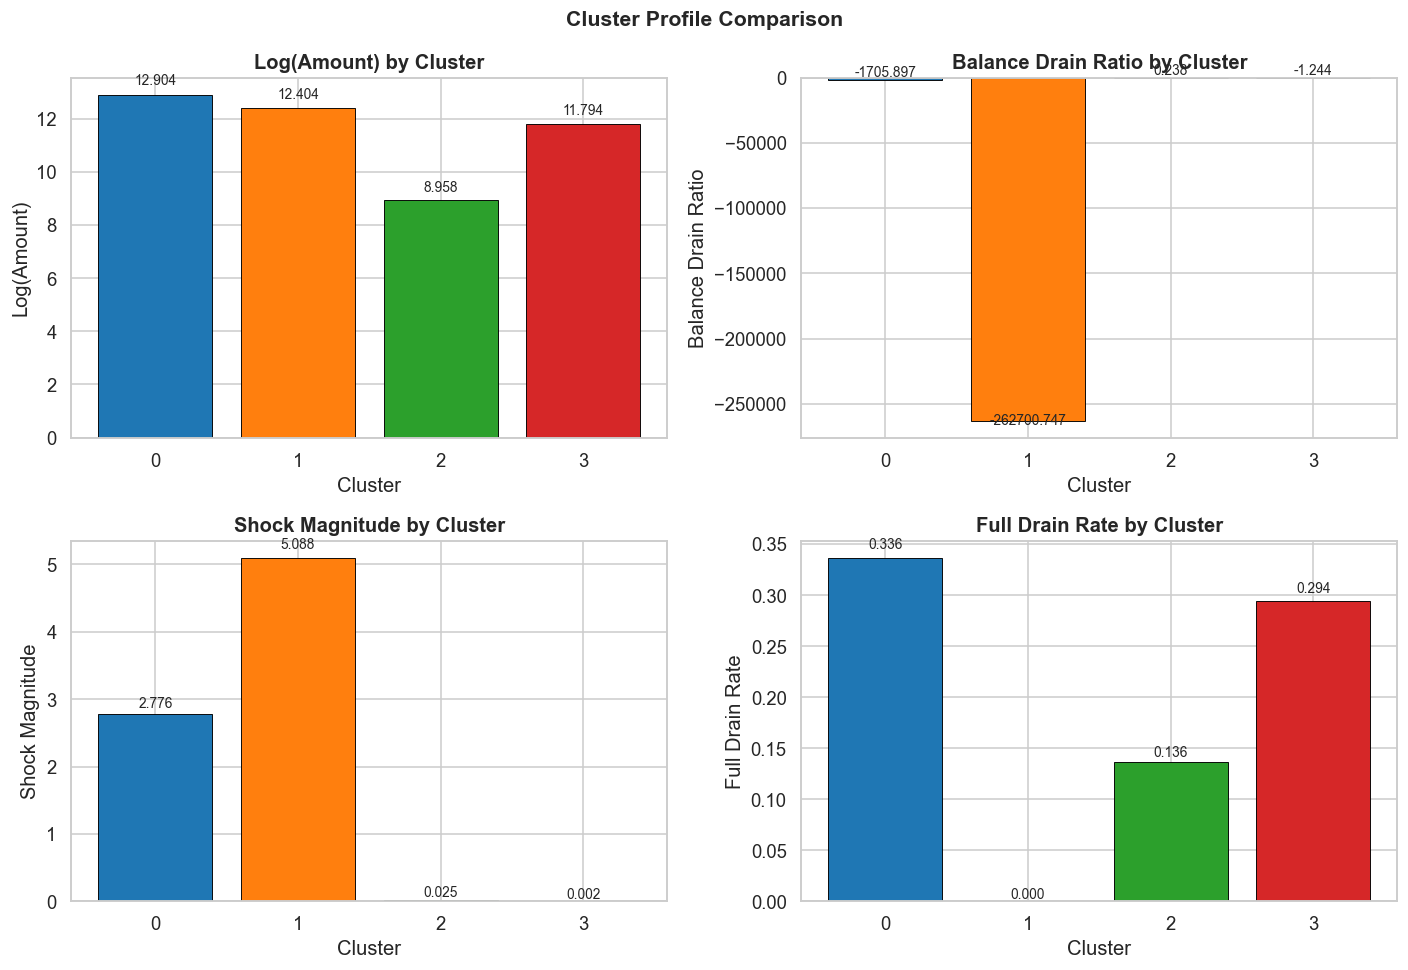

In [26]:
# Profile comparison across clusters
compare_metrics = {
    'log_amount'          : 'Log(Amount)',
    'balance_change_ratio': 'Balance Drain Ratio',
    'shock_magnitude'     : 'Shock Magnitude',
    'full_drain'          : 'Full Drain Rate',
}
cluster_means = df.groupby('cluster_label')[list(compare_metrics.keys())].mean()

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, label) in zip(axes.flatten(), compare_metrics.items()):
    vals = cluster_means[col]
    bars = ax.bar(vals.index.astype(str), vals.values,
                  color=[palette_cls[i] for i in vals.index], edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{label} by Cluster', fontweight='bold')
    ax.set_xlabel('Cluster'); ax.set_ylabel(label)

plt.suptitle('Cluster Profile Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

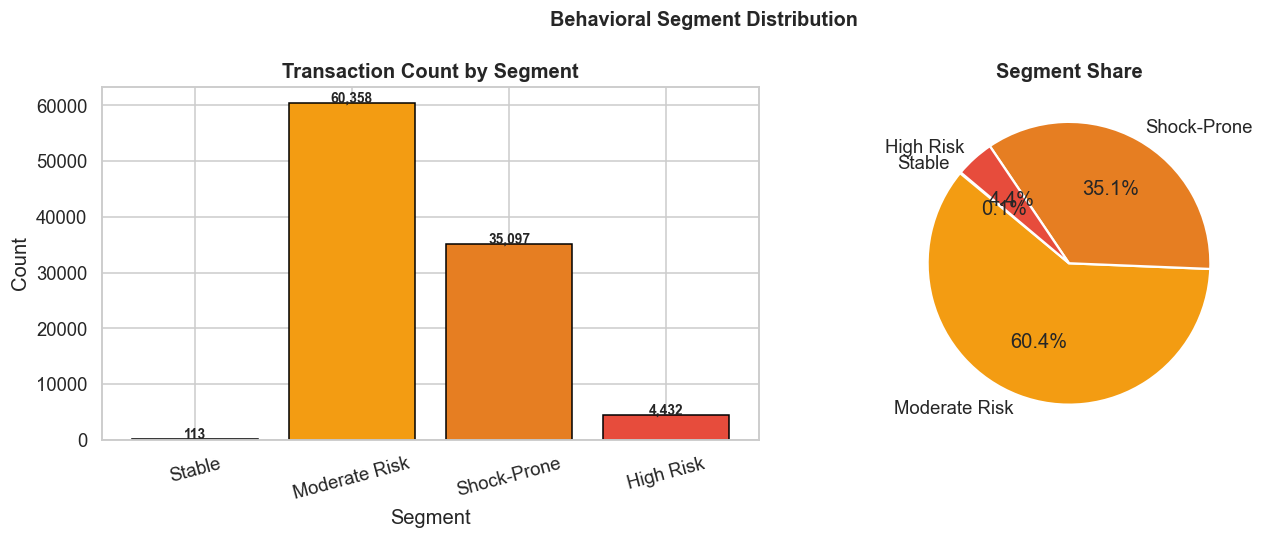

In [27]:
# Segment distribution
seg_order  = ['Stable', 'Moderate Risk', 'Shock-Prone', 'High Risk']
seg_counts = df['segment'].value_counts().reindex(
    [s for s in seg_order if s in df['segment'].unique()], fill_value=0)
seg_colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'][:len(seg_counts)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor='black')
for bar, v in zip(bars, seg_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{v:,}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Transaction Count by Segment', fontweight='bold')
axes[0].set_xlabel('Segment'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

axes[1].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=seg_colors, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Segment Share', fontweight='bold')

plt.suptitle('Behavioral Segment Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Persona Reference

| Persona | Risk Level | Interpretation |
|---------|-----------|---------------|
| **Stable** | Low | Routine, low-amount transactions with minimal balance impact. No shock indicators present. Standard monitoring applies. |
| **Moderate Risk** | Medium | Occasional anomalies with moderate balance changes. Shocks resolve quickly. Periodic review recommended. |
| **Shock-Prone** | Medium-High | Elevated shock frequency and significant balance drain. Gradual recovery pattern. Flag for enhanced monitoring. |
| **High Risk** | High | High shock magnitude, frequent full account drains, elevated fraud rate. Requires immediate review and intervention. |

In [28]:
# Cluster summary table
cluster_summary = df.groupby(['cluster_label', 'segment']).agg(
    n_transactions      = ('shock_event',          'count'),
    shock_rate          = ('shock_event',          'mean'),
    avg_shock_magnitude = ('shock_magnitude',      'mean'),
    full_drain_rate     = ('full_drain',           'mean'),
    fraud_rate          = ('isFraud',              'mean'),
    avg_FSI             = ('FSI',                  'mean'),
).round(4).reset_index()

display(cluster_summary)

,cluster_label,segment,n_transactions,shock_rate,avg_shock_magnitude,full_drain_rate,fraud_rate,avg_FSI
0,0,High Risk,4432,0.9984,2.7755,0.3360,0.0269,0.9310
1,1,Stable,113,1.0000,5.0875,0.0000,0.0000,0.7812
2,2,Shock-Prone,35097,0.0127,0.0249,0.1361,0.0003,0.4789
3,3,Moderate Risk,60358,0.0010,0.0017,0.2939,0.0002,0.5164


## 8. Conclusion

- **Financial shocks are multi-dimensional:** No single feature reliably identifies anomalous transactions. The combination of balance drain indicators, amount-to-balance ratios, and binary structural signals (`full_drain`, `no_dest_credit`, `amount_mismatch`) produces the most discriminative feature set.

- **Ensemble anomaly detection improves recall:** Isolation Forest and DBSCAN flag complementary subsets of anomalies. Their union — measured by Jaccard similarity — confirms that each model captures patterns the other misses, and the combined label reduces false negatives.

- **Clustering produces interpretable risk segments:** Four behavioral personas — Stable, Moderate Risk, Shock-Prone, and High Risk — show materially different shock rates, drain frequencies, and fraud rates, validating the segmentation as operationally meaningful.

- **The Financial Stress Index enables continuous risk monitoring:** FSI values correlate monotonically with shock rate, balance drain, and fraud rate across tiers, confirming the index captures genuine risk gradations rather than noise.

- **Unsupervised learning is the correct paradigm:** The absence of pre-labelled shock data makes supervised approaches inapplicable. The pipeline demonstrates that structure, risk ranking, and actionable segments can be discovered entirely from transaction dynamics.

- **Business relevance:** The output — an enriched dataset with per-transaction shock labels, recovery classes, risk personas, and FSI scores — can be directly integrated into transaction monitoring systems, fraud triage pipelines, and risk-based customer profiling workflows.

## 9. Exports

In [31]:
# Final output — enriched dataset and exports
OUTPUT_COLS = [
    'step', 'type', 'amount', 'nameOrig', 'nameDest',
    'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
    'log_amount', 'balance_drain', 'balance_change_ratio', 'full_drain',
    'no_dest_credit', 'amount_mismatch', 'hour', 'day',
    'iso_score', 'iso_shock', 'dbscan_shock', 'shock_event', 'shock_magnitude',
    'cluster_kmeans', 'cluster_gmm', 'cluster_label', 'segment',
    'FSI', 'fsi_tier',
]

final_df = df[OUTPUT_COLS].copy()
print(f"Final enriched dataset: {final_df.shape}")
final_df.head(5)

Final enriched dataset: (100000, 29)


,step,type,amount,nameOrig,nameDest,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,...,iso_shock,dbscan_shock,shock_event,shock_magnitude,cluster_kmeans,cluster_gmm,cluster_label,segment,FSI,fsi_tier
0,1,CASH_OUT,132038.41,C1324514662,C998351292,0.0,0.00,230103.96,1015132.48,0,...,0,0,0,0.000000,3,3,3,Moderate Risk,0.516014,Medium Risk
1,1,PAYMENT,1824.59,C1384563514,M1852661033,25138.0,23313.41,0.00,0.00,0,...,0,0,0,0.000000,2,2,2,Shock-Prone,0.452205,Low Risk
2,1,PAYMENT,1203.44,C922807452,M33563464,29941.0,28737.56,0.00,0.00,0,...,0,0,0,0.000000,2,2,2,Shock-Prone,0.446006,Low Risk
3,1,PAYMENT,997.34,C1285463992,M10405169,103876.0,102878.66,0.00,0.00,0,...,1,0,1,1.967781,2,0,2,Shock-Prone,0.843209,High Risk
4,1,PAYMENT,5029.67,C1349872758,M950729555,0.0,0.00,0.00,0.00,0,...,0,0,0,0.000000,2,2,2,Shock-Prone,0.467313,Low Risk


In [32]:
final_df.to_csv('final_transactions_enriched.csv', index=False)
cluster_summary.to_csv('cluster_summary.csv', index=False)
seg_profile.reset_index().to_csv('segment_profiles.csv', index=False)

print("Exports complete:")
print("  final_transactions_enriched.csv")
print("  cluster_summary.csv")
print("  segment_profiles.csv")

PermissionError: [Errno 13] Permission denied: 'segment_profiles.csv'